# Rae2822 2D Wing Slice Model

### Import Library

In [ ]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

### Loading Data

In [3]:
# angles = range(21)

folder_path = "./data/rae2822/angvar_sa/"
angles = sorted(glob.glob(f"{folder_path}*"), key=lambda x: float(x.split('\\')[-1]))
files = sorted(glob.glob(f"{folder_path}*/surface_flow.csv"))

master_df = []

for i, filepath in enumerate(angles):
    df = pd.read_csv(filepath+"/surface_flow.csv")

    # apply angles for each case
    df['AoA'] = float(angles[i].split('\\')[-1])

    master_df.append(df)

# Combine into one training set
full_data = pd.concat(master_df, ignore_index=True)
full_data = full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']]
# full_data = full_data.dropna()
print(full_data[full_data.isna().any(axis=1)])


Empty DataFrame
Columns: [Pressure_Coefficient, AoA, x, y]
Index: []


In [4]:
print(f"Total rows: {len(full_data)}")
full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']].head(300)

Total rows: 8256


,Pressure_Coefficient,AoA,x,y
0,0.262408,0.0,0.985397,0.000943
1,0.279663,0.0,0.969573,0.001489
2,0.293002,0.0,0.952680,0.001679
3,0.295781,0.0,0.934996,0.001511
4,0.292556,0.0,0.916822,0.000923
...,...,...,...,...
295,-0.423432,0.5,0.031993,0.022736
296,-0.428776,0.5,0.035372,0.023828
297,-0.431730,0.5,0.038915,0.024920
298,-0.443075,0.5,0.042590,0.026014


Text(0.5, 1.0, 'Sample Case: AoA = 6°')

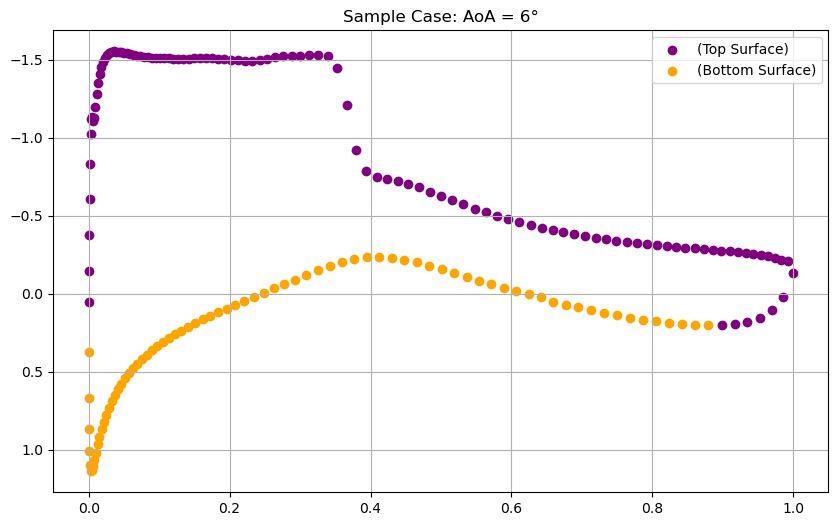

In [56]:
sample_aoa = 6
sample_case = full_data[full_data['AoA'] == sample_aoa]

plt.figure(figsize=(10, 6))
top_surface = sample_case[sample_case['y'] > 0].sort_values(by='x')
bottom_surface = sample_case[sample_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Pressure_Coefficient'], color='purple', label='(Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Pressure_Coefficient'],color='orange', label='(Bottom Surface)')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.title(f"Sample Case: AoA = {sample_aoa}°")

# Model

In [6]:
# import model
import tensorflow as tf
from sklearn.model_selection import LeaveOneGroupOut

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [47]:
full_data['AoA_rad'] = np.deg2rad(full_data['AoA'])
full_data['sin_AoA'] = np.sin(full_data['AoA_rad'])
full_data['cos_AoA'] = np.cos(full_data['AoA_rad'])

# features = ['x', 'y', 'AoA']
features = ['x', 'y', 'sin_AoA', 'cos_AoA']
target = 'Pressure_Coefficient'

In [ ]:
logo = LeaveOneGroupOut()

architecture = [
        tf.keras.layers.Dense(64, activation='relu', input_shape=(4,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1)
    ]


early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,          # wait 15 epochs without improvement
        restore_best_weights=True
    )

aoa_values = full_data['AoA'].values
unique_aoas = np.unique(aoa_values)
X = full_data[features].values  # shape (n*192, 3)
y = full_data[target].values    # shape (n*192, 1)

val_scores = []
train_val_ratio = []
_round = 0

for train_idx, test_idx in logo.split(X, y, aoa_values):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = tf.keras.Sequential(architecture)

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=200,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=0
    )

    final_train = history.history['loss'][-1]
    actual_epochs = len(history.history['loss'])
    final_val   = history.history['val_loss'][-1]
    gap_ratio   = final_val / final_train

    score = model.evaluate(X_test, y_test, verbose=0)
    val_scores.append(score)
    train_val_ratio.append(gap_ratio)
    print(f"AoA {unique_aoas[_round]} → train: {final_train:.5f} | val: {final_val:.5f} | ratio: {gap_ratio:.2f}")
    print(f"\tStopped at epoch: {actual_epochs}")
    _round += 1

print(f"\nMean MSE: {np.mean(val_scores):.4f}")

c:\Users\KongP\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AoA 0.0 → train: 0.00216 | val: 0.01127 | ratio: 5.21
	Stopped at epoch: 111
AoA 0.5 → train: 0.00267 | val: 0.00208 | ratio: 0.78
	Stopped at epoch: 40
AoA 1.0 → train: 0.00226 | val: 0.00242 | ratio: 1.07
	Stopped at epoch: 29
AoA 1.5 → train: 0.00184 | val: 0.00234 | ratio: 1.27
	Stopped at epoch: 16
AoA 2.0 → train: 0.00172 | val: 0.00101 | ratio: 0.59
	Stopped at epoch: 39
AoA 2.5 → train: 0.00189 | val: 0.00124 | ratio: 0.66
	Stopped at epoch: 22
AoA 3.0 → train: 0.00117 | val: 0.00144 | ratio: 1.24
	Stopped at epoch: 36
AoA 3.5 → train: 0.00312 | val: 0.00107 | ratio: 0.34
	Stopped at epoch: 24
AoA 4.0 → train: 0.00277 | val: 0.00082 | ratio: 0.30
	Stopped at epoch: 16
AoA 4.5 → train: 0.00109 | val: 0.00087 | ratio: 0.80
	Stopped at epoch: 22
AoA 5.0 → train: 0.00114 | val: 0.00058 | ratio: 0.51
	Stopped at epoch: 54
AoA 5.5 → train: 0.00098 | val: 0.00118 | ratio: 1.20
	Stopped at epoch: 22
AoA 6.0 → train: 0.00139 | val: 0.00190 | ratio: 1.37
	Stopped at epoch: 33
AoA 6.5 → t

In [13]:
unique_aoas = np.unique(aoa_values)
for i, (aoa, score, ratio) in enumerate(zip(unique_aoas, val_scores, train_val_ratio)):
    print(f"AoA {aoa }° → MSE: {score[0]:.4f}, Ratio: {ratio:.2f}")

AoA 0.0° → MSE: 0.0016, Ratio: 5.21
AoA 0.5° → MSE: 0.0004, Ratio: 0.78
AoA 1.0° → MSE: 0.0006, Ratio: 1.07
AoA 1.5° → MSE: 0.0005, Ratio: 1.27
AoA 2.0° → MSE: 0.0009, Ratio: 0.59
AoA 2.5° → MSE: 0.0007, Ratio: 0.66
AoA 3.0° → MSE: 0.0005, Ratio: 1.24
AoA 3.5° → MSE: 0.0005, Ratio: 0.34
AoA 4.0° → MSE: 0.0006, Ratio: 0.30
AoA 4.5° → MSE: 0.0006, Ratio: 0.80
AoA 5.0° → MSE: 0.0004, Ratio: 0.51
AoA 5.5° → MSE: 0.0004, Ratio: 1.20
AoA 6.0° → MSE: 0.0004, Ratio: 1.37
AoA 6.5° → MSE: 0.0002, Ratio: 0.31
AoA 7.0° → MSE: 0.0003, Ratio: 1.22
AoA 7.5° → MSE: 0.0005, Ratio: 1.55
AoA 8.0° → MSE: 0.0003, Ratio: 4.69
AoA 8.5° → MSE: 0.0003, Ratio: 5.35
AoA 9.0° → MSE: 0.0003, Ratio: 1.30
AoA 9.5° → MSE: 0.0005, Ratio: 2.71
AoA 10.0° → MSE: 0.0004, Ratio: 0.56
AoA 10.25° → MSE: 0.0002, Ratio: 0.35
AoA 10.5° → MSE: 0.0002, Ratio: 2.59
AoA 10.75° → MSE: 0.0003, Ratio: 1.43
AoA 11.0° → MSE: 0.0003, Ratio: 0.43
AoA 11.25° → MSE: 0.0002, Ratio: 2.63
AoA 11.5° → MSE: 0.0003, Ratio: 1.20
AoA 11.75° → MSE: 

In [ ]:
# train final model with full dataset
full_feature = full_data[features]
full_target = full_data[target]
final_model = tf.keras.Sequential(architecture)

final_model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['accuracy']
    )
final_model.fit(
        full_feature, full_target,
        epochs=200,
        callbacks=[early_stop],
        verbose=0
    )


c:\Users\KongP\Anaconda\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


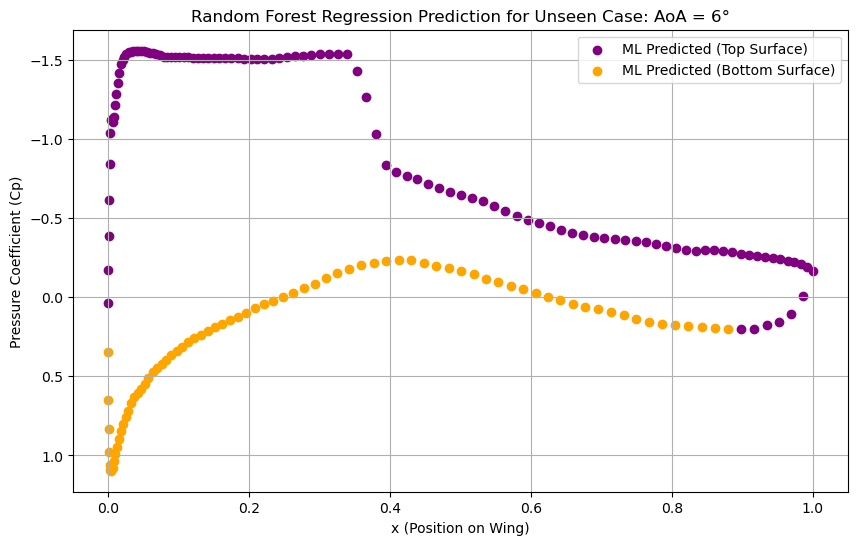

In [29]:
predict_aoa = 6

geometry = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)

X_new = full_data[full_data['AoA'] == 0.0][features].copy().reset_index(drop=True)
X_new['sin_AoA'] = np.sin(np.deg2rad(predict_aoa))
X_new['cos_AoA'] = np.cos(np.deg2rad(predict_aoa))

# predict
Cp_predicted = final_model.predict(X_new)

# map back — just attach prediction to the same rows
result = X_new[features].copy()
result['Cp_predicted'] = Cp_predicted

# print(result)


plt.figure(figsize=(10, 6))
top_surface = result[result['y'] > 0].sort_values(by='x')
bottom_surface = result[result['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Cp_predicted'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Cp_predicted'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title(f"Random Forest Regression Prediction for Unseen Case: AoA = {predict_aoa}°")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
aoa_degrees = np.linspace(0, 360, 100)
aoa_radians = np.deg2rad(aoa_degrees)

# 2. Apply the Trigonometric Normalization
sin_aoa = np.sin(aoa_radians)
cos_aoa = np.cos(aoa_radians)

# 3. Create a side-by-side visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: The Bounded Waves ---
ax1.plot(aoa_degrees, sin_aoa, label='sin_AoA', color='blue', linewidth=2)
ax1.plot(aoa_degrees, cos_aoa, label='cos_AoA', color='red', linewidth=2, linestyle='--')
ax1.set_title("1. Bounding Features between [-1, 1]")
ax1.set_xlabel("Original Angle of Attack (Degrees)")
ax1.set_ylabel("Normalized Feature Value")
ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax1.legend()
ax1.grid(True, alpha=0.4)

# --- Plot 2: The Unit Circle Projection ---
# We use color to map back to the original angle
cmap = plt.cm.cool
scatter = ax2.scatter(cos_aoa, sin_aoa, c=aoa_degrees, cmap='twilight_shifted', edgecolor='k')
ax2.set_title("2. New Feature Space (Cyclical Continuity)")
ax2.set_xlabel("cos_AoA")
ax2.set_ylabel("sin_AoA")
ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax2.axvline(0, color='black', linewidth=0.8, linestyle=':')
ax2.set_aspect('equal') # Forces the axes to be proportional (perfect circle)
plt.colorbar(scatter, ax=ax2, label='Original AoA (Degrees)')

plt.tight_layout()
plt.show()

UsageError: Cell magic `%%skip` not found.
